# -1. heapq 모듈 사용하기

In [ ]:
import heapq

In [ ]:
min_heap = []
heapq.heappush(min_heap, 2)
heapq.heappush(min_heap, 1)
heapq.heappush(min_heap, 6)
heapq.heappush(min_heap, 3)
heapq.heappush(min_heap, 7)

In [ ]:
heapq.heappop(min_heap)

1

1 삭제, 반환(return)

In [ ]:
heapq.heappop(min_heap)

2

In [ ]:
heapq.heappop(min_heap)

3

In [ ]:
heapq.heappop(min_heap)

6

In [ ]:
heapq.heappop(min_heap)

7

# 0. Queue 연결리스트를 통한 heapQueue 구현

In [ ]:
import time

class Node:
  def __init__(self, data):
    self.data = data
    self.next = None


class heapQueue:

  def __init__(self):
    self.front = None
    self.tail = None

  def enQueue(self, num):
    new = Node(num)
    if self.tail == None:
      self.front = new
      self.tail = new
      return

    if num < self.front.data:
      new.next = self.front
      self.front = new
      return

    cur = self.front
    while cur.next != None and cur.next.data <= num:
        cur = cur.next

    new.next = cur.next
    cur.next = new

    if new.next == None:
        self.tail = new

  def deQueue(self):
    if self.front == None:# 빈칸: 빈 큐일 때 "dequeue FAIL: Queue is empty." 출력
      print("dequeue FAIL: Queue is empty")
    else:
      data = self.front.data
      if self.front == self.tail:# 빈칸: 노드가 한 개 남았을 때의 삭제
        self.tail = self.front = None
      else:# 빈칸: 두 개 이상의 노드가 남았을 때의 삭제
        self.front = self.front.next
      return data

  def printQueue(self):
    cur = self.front
    print("Queue: ", end="")
    if cur == None:
      print("is empty.")
    else:
      while cur is not None:
        print(cur.data, " ")
        cur=cur.next
      #빈칸

In [ ]:
qp = heapQueue()
qp.enQueue(1)
qp.enQueue(5)
qp.enQueue(3)

In [ ]:
qp.deQueue()

1

In [ ]:
qp.deQueue()

3

In [ ]:
qp.deQueue()

5

# 1. Heap 자료 구조를 활용한 우선순위 큐 구현(의 시행착오)

(1) enQueue

In [ ]:
heap = []
tail = 0
while 1:
  n = int(input("숫자를 입력하세요."))
  if n == 100:
    break
  heap.append(n)
  t = int(len(heap))-1

  while len(heap)>1:
    p = t//2
    print(p)
    if heap[p]>heap[t]:
      heap[t], heap[p] = heap[p], heap[t]
      t = p
    else:
      break

print(heap)

숫자를 입력하세요.3
숫자를 입력하세요.4
0
숫자를 입력하세요.5
1
숫자를 입력하세요.6
1
숫자를 입력하세요.7
2
숫자를 입력하세요.2
2
1
0
0
숫자를 입력하세요.3
3
1
숫자를 입력하세요.4
3


KeyboardInterrupt: Interrupted by user

(2) deQueue 구현

In [ ]:
# deQueue
heap = [1, 4, 6, 21, 30]

print('반환: ', heap[0])

heap[0]=heap[-1]
del heap[-1]
my = 0
while True:
  m = my*2+1
  if m>len(heap):
    break
  if heap[m]==heap[-1]:
    a=heap[m]
    heap[m]=heap[my]
    heap[my]=a
    break

  if heap[m]<heap[m+1]:
    a=heap[m]
    heap[m]=heap[my]
    heap[my]=a
    my=m
  else:
    a=heap[m+1]
    heap[m+1]=heap[my]
    heap[my]=a
    my=m+1

print("결과: ", heap)
# 단점: 아직 최적화되어있지 않은 상태 => heapQueue클래스를 구현하며 수정된 사항

# 2. heapQueue 클래스 구현

(1) min priority heap 구현

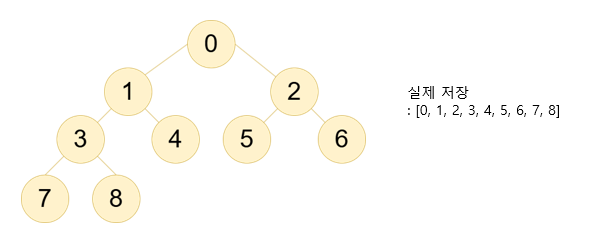

In [ ]:
class heapQueue:

  def __init__(self):
    self.heap = []

  def enQueue(self, num):

    self.heap.append(num)
    len1 = len(self.heap)-1

    p = (len1-1)//2
    while self.heap[p]>self.heap[len1]:
      self.heap[p], self.heap[len1] = self.heap[len1], self.heap[p]
      len1 = p
      p = (p-1)//2
      if p<0:
        break


  def deQueue(self):

    if not self.heap:
      print("heap is empty")
      return None

    root = self.heap[0]
    self.heap[0] = self.heap[-1]
    self.heap.pop()

    n = len(self.heap)
    i = 0

    while True:
      child = 2*i + 1   # 왼쪽 자식

      if child >= n:
        break

      # 오른쪽 자식이 더 작으면 오른쪽 선택
      if child + 1 < n and self.heap[child+1] < self.heap[child]:
        child += 1

      if self.heap[i] <= self.heap[child]:
        break

      self.heap[i], self.heap[child] = self.heap[child], self.heap[i]
      i = child

    return root

  def printQueue(self):
    if len(self.heap) == 0:
      print("Queue is empty.")
    else:
      print(self.heap)

In [ ]:
qp = heapQueue()
qp.enQueue(1)
qp.enQueue(3)
qp.enQueue(7)
qp.enQueue(19)
qp.enQueue(14)
qp.enQueue(17)

In [ ]:
qp.printQueue()

[1, 3, 7, 19, 14, 17]


In [ ]:
qp.deQueue()

1

In [ ]:
qp.printQueue()

[3, 14, 7, 19, 17]


(2) max priority heap 구현

In [ ]:
class maxPriority:

  def __init__(self):
    self.heap = []

  def enQueue(self, num):

    self.heap.append(num)
    len1 = len(self.heap)-1

    p = (len1-1)//2
    while self.heap[p]<self.heap[len1]: #부등호 반대
      self.heap[p], self.heap[len1] = self.heap[len1], self.heap[p]
      len1 = p
      p = (p-1)//2
      if p<0:
        break


  def deQueue(self):

    if not self.heap:
      print("heap is empty")
      return None

    root = self.heap[0]
    self.heap[0] = self.heap[-1]
    self.heap.pop()

    n = len(self.heap)
    i = 0

    while True:
      child = 2*i + 1   # 왼쪽 자식

      if child >= n:
        break

      if child + 1 < n and self.heap[child+1] > self.heap[child]: #두번째 부등호 반대
        child += 1

      if self.heap[i] >= self.heap[child]:
        break

      self.heap[i], self.heap[child] = self.heap[child], self.heap[i]
      i = child

    return root

  def printQueue(self):
    if len(self.heap) == 0:
      print("Queue is empty.")
    else:
      print(self.heap)

# 3. 응급실 환자 관리 프로그램

<문제 조건>


*   새로운 환자가 온다 -> enqueue
*   진료를 시작한다 -> dequeue

---
<우선순위 점수 계산 방식>
* 중증도: 1~5단계, x 10가산
* 나이: 10세 이하 또는 65세 이상인 경우 +5가산
* 의식 수준: 무의식/혼미/정상, 각각 +10 / +5 / +0 가산





In [ ]:
#튜플 대소 비교를 이용한 프로그램(시간복잡도가 더 작음)
#환자 우선순위 점수 계산
def rank(b, age, c): # b: 중증도, age: 나이, 의식 수준: c
  # rank = 우선순위 점수

  rank = 10 * b #중증도 x 10 가산

  if age <= 10 or age >= 65: #10세 이하 또는 65세 이상
    rank += 5

  if c == "무의식":# 의식 수준에 따른 가산
    rank += 10
  elif c == "혼미":
    rank += 5

  return rank #우선순위 점수 반환

import time
line = maxPriority() #점수가 높을수록 응급이기 때문에 maxpriority 사용
while 1:
  a = int(input("새로운 환자 : 0, 진료 준비 완료 : 1 "))

  # 새로운 환자 입력
  if a == 0:
    name = input("이름 (또는 식별 번호)를 입력하시오. ")
    b = int(input("중증도(1~5단계)를 입력하시오. "))
    age = int(input("나이를 입력하시오. "))
    c = input("의식수준을 입력하시오.(무의식/혼미/정상) ")
    t=time.time() #현재 시각 저장
    score = rank(b, age, c) #우선순위 점수 계산1

    line.enQueue((score, -t, name))

  #진료 시작
  elif a == 1:
    if len(line.heap) == 0: #환자가 없을 때 #프로그램 종료
      print("대기열에 환자가 없습니다.")
      break
    else:
      s, times, name = line.deQueue() # 가장 높은 우선순위 점수 추출
      print(f"다음 진료는 {name} 환자입니다.")

새로운 환자 : 0, 진료 준비 완료 : 1 0
이름 (또는 식별 번호)를 입력하시오. 송연경
중증도(1~5단계)를 입력하시오. 4
나이를 입력하시오. 70
의식수준을 입력하시오.(무의식/혼미/정상) 혼미
새로운 환자 : 0, 진료 준비 완료 : 1 0
이름 (또는 식별 번호)를 입력하시오. 황현민
중증도(1~5단계)를 입력하시오. 4
나이를 입력하시오. 20
의식수준을 입력하시오.(무의식/혼미/정상) 무의식
새로운 환자 : 0, 진료 준비 완료 : 1 0
이름 (또는 식별 번호)를 입력하시오. 최은수
중증도(1~5단계)를 입력하시오. 3
나이를 입력하시오. 9
의식수준을 입력하시오.(무의식/혼미/정상) 정상
새로운 환자 : 0, 진료 준비 완료 : 1 0
이름 (또는 식별 번호)를 입력하시오. 주윤재
중증도(1~5단계)를 입력하시오. 5
나이를 입력하시오. 20
의식수준을 입력하시오.(무의식/혼미/정상) 무의식
새로운 환자 : 0, 진료 준비 완료 : 1 1
다음 진료는 주윤재 환자입니다.
새로운 환자 : 0, 진료 준비 완료 : 1 1
다음 진료는 송연경 환자입니다.
새로운 환자 : 0, 진료 준비 완료 : 1 1
다음 진료는 황현민 환자입니다.
새로운 환자 : 0, 진료 준비 완료 : 1 1
다음 진료는 최은수 환자입니다.
새로운 환자 : 0, 진료 준비 완료 : 1 1
대기열에 환자가 없습니다.


In [ ]:
#딕셔너리를 활용한 코드
#환자 우선순위 점수 계산
def rank(b, age, c): # b: 중증도, age: 나이, 의식 수준: c
  # rank = 우선순위 점수

  rank = 10 * b #중증도 x 10 가산

  if age <= 10 or age >= 65: #10세 이하 또는 65세 이상
    rank += 5

  if c == "무의식":# 의식 수준에 따른 가산
    rank += 10
  elif c == "혼미":
    rank += 5

  return rank #우선순위 점수 반환

lst = {} #환자별 중증도 저장(key : 환자 이름, value : 우선순위 점수)
line = maxPriority() #점수가 높을수록 응급이기 때문에 maxpriority 사용
while 1:
  a = int(input("새로운 환자 : 0, 진료 준비 완료 : 1 "))

  # 새로운 환자 입력
  if a == 0:
    name = input("이름 (또는 식별 번호)를 입력하시오. ")
    b = int(input("중증도(1~5단계)를 입력하시오. "))
    age = int(input("나이를 입력하시오. "))
    c = input("의식수준을 입력하시오.(무의식/혼미/정상) ")

    score = rank(b, age, c) #우선순위 점수 계산
    lst[name] = score # 이름과 우선순위 딕셔너리에 저장
    line.enQueue(score) #우선순위점수 힙에 저장

  #진료 시작
  elif a == 1:
    if len(lst) == 0: #환자가 없을 때 #프로그램 종료
      print("대기열에 환자가 없습니다.")
      break
    else:
      s = line.deQueue() # 가장 높은 우선순위 점수 추출
      for key, value in lst.items(): # 가장 높은 우선순위에 있는 환자 이름 찾기
        if value == s:
          print(f"다음 진료는 {key} 환자입니다.")
          del lst[key]
          break
        else:
          continue

# 4. 다익스트라 알고리즘 구현

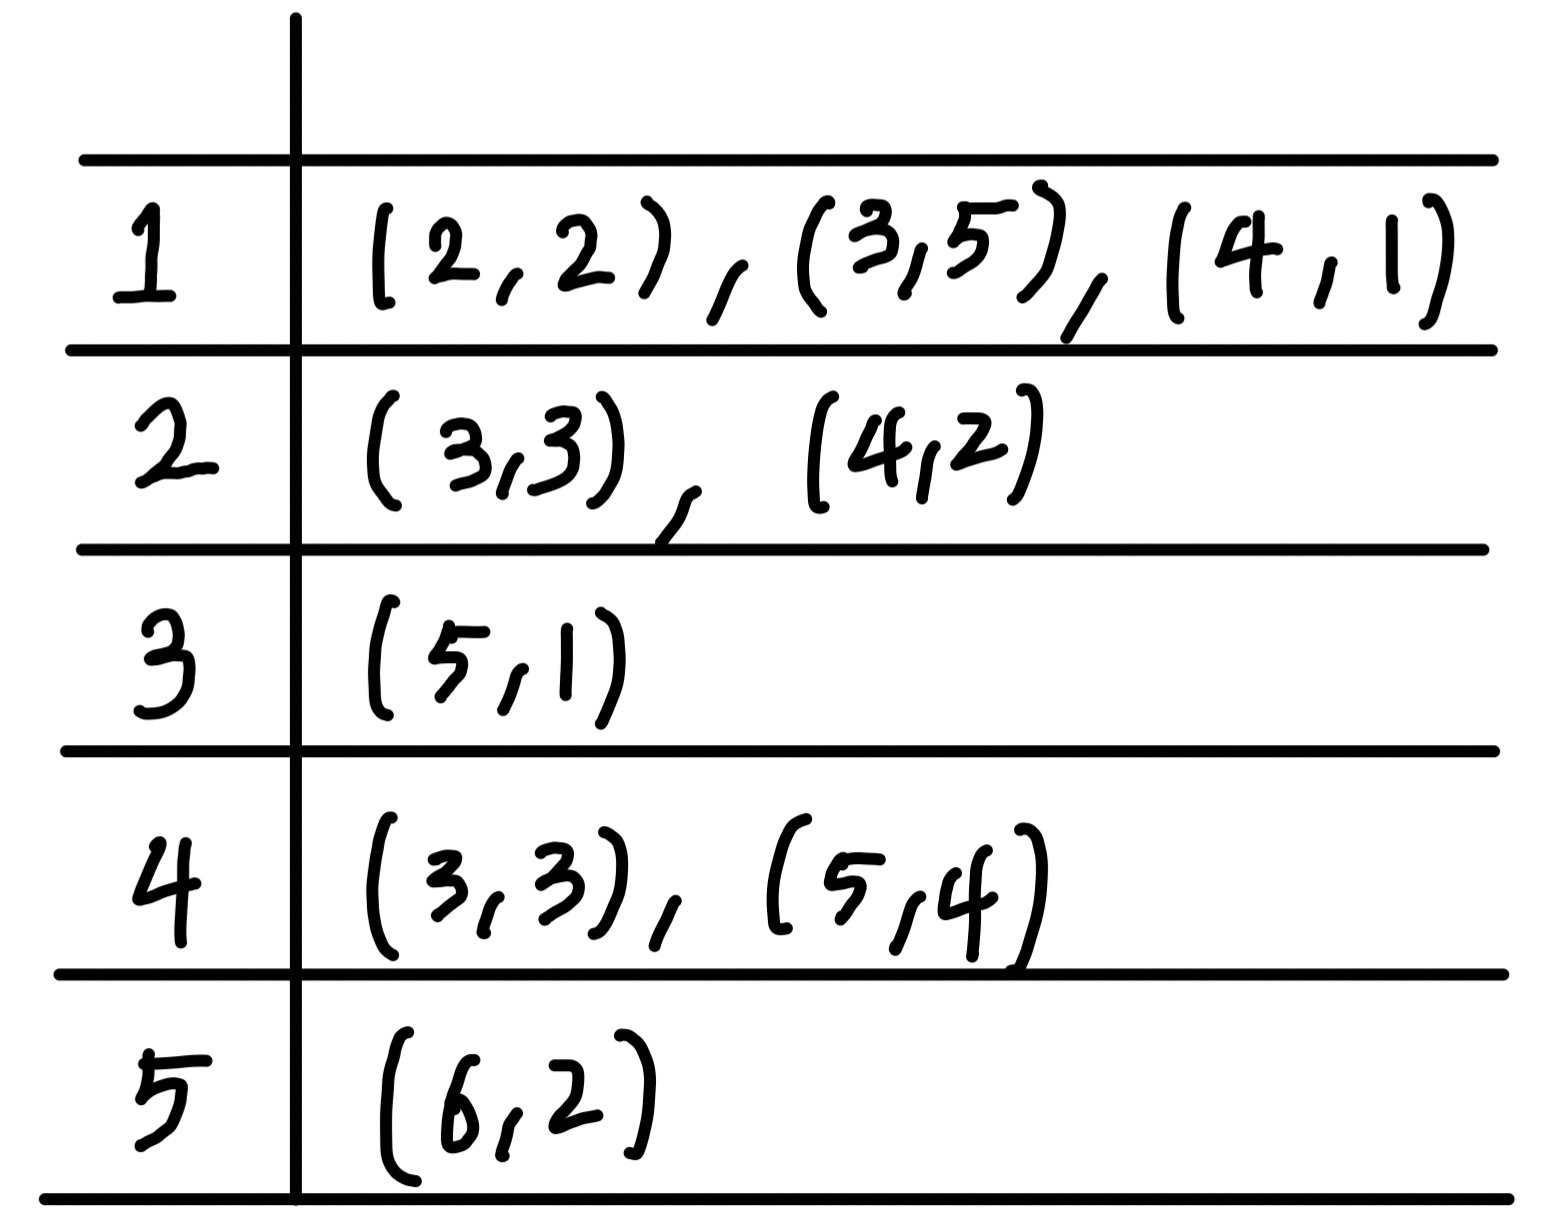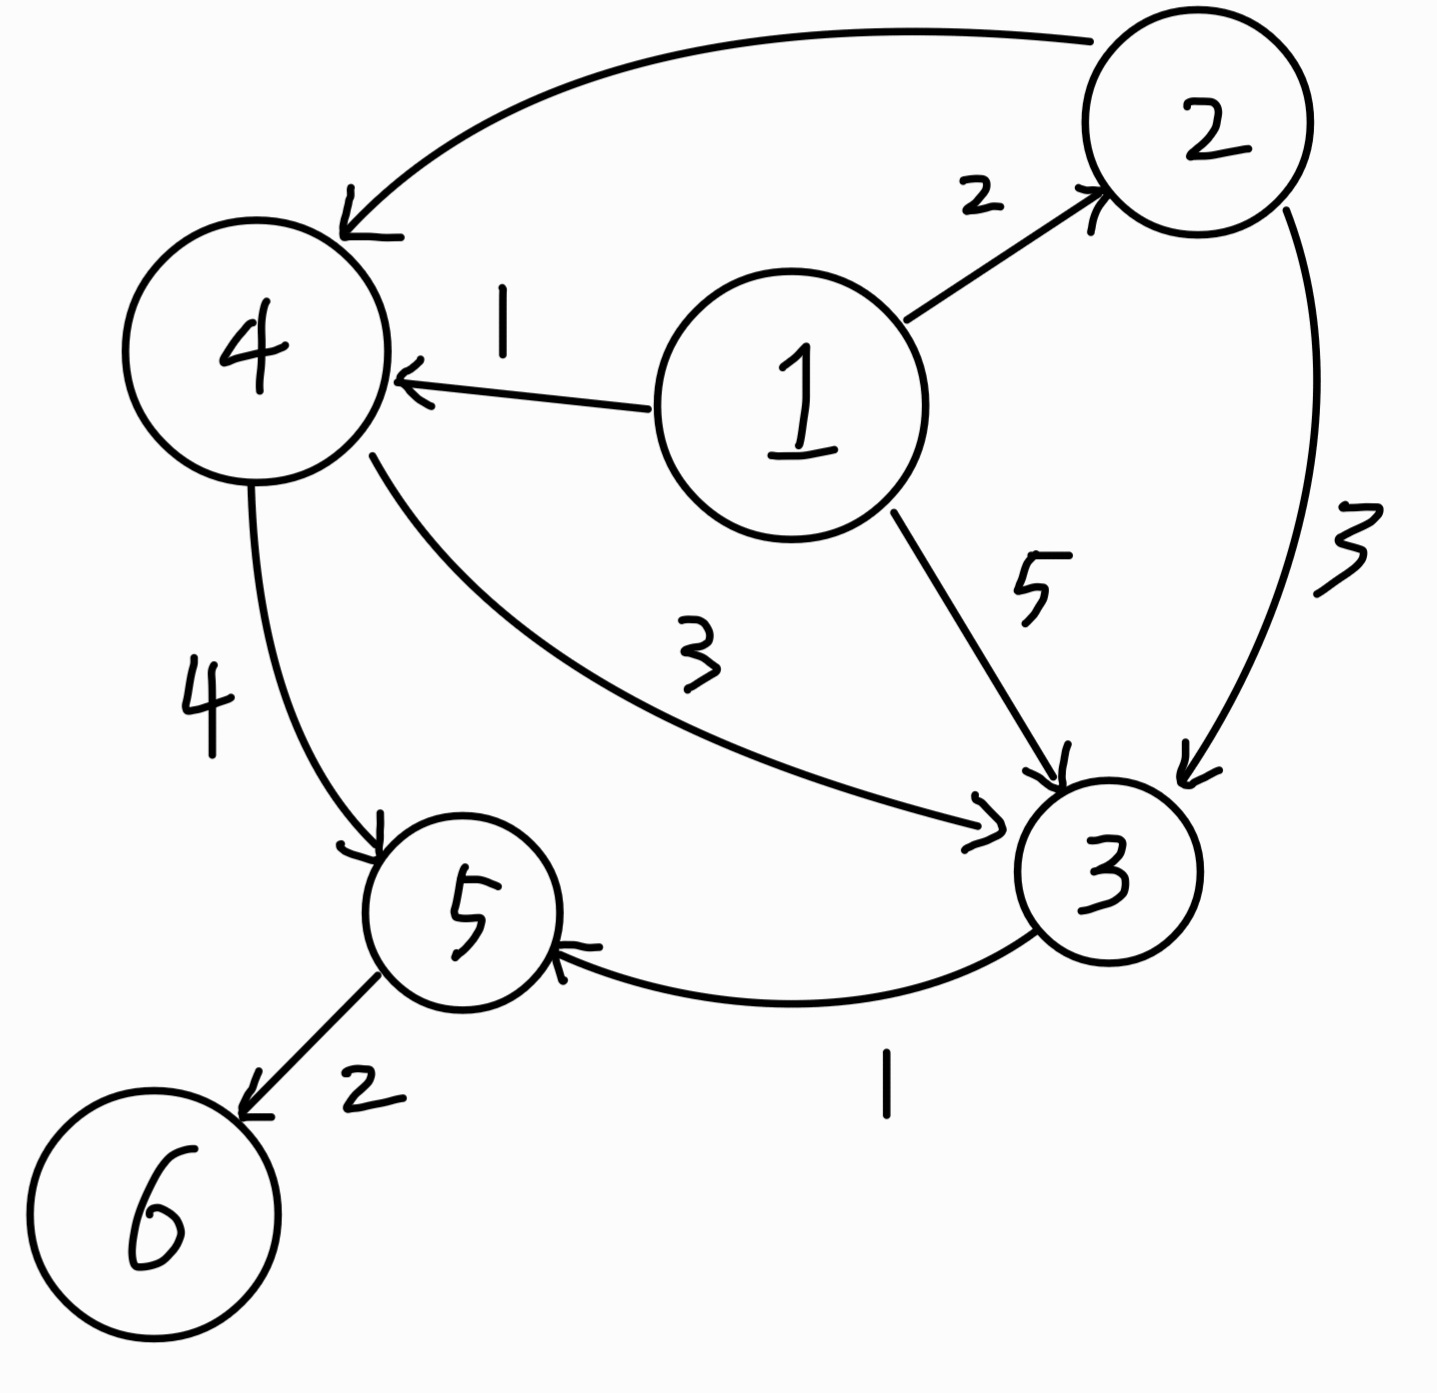

In [ ]:
# heapq 모듈을 사용하여 먼저 구현
# astar = heapQueue()
# import heapq

# n, m = map(int, input().split())   # 도시 수, 도로 수
# start = int(input())               # 시작 도시

# graph = [[] for _ in range(n+1)]

# for _ in range(m):
#     a, b, c = map(int, input().split())
#     graph[a].append((b, c))

# INF = 10**9
# dist = [INF] * (n+1)
# dist[start] = 0

# heap = []
# heapq.heappush(heap, (0, start))

# while heap:
#     d, now = heapq.heappop(heap)

#     if dist[now] < d:
#         continue

#     for next_node, cost in graph[now]:
#         new_cost = d + cost

#         if new_cost < dist[next_node]:
#             dist[next_node] = new_cost
#             heapq.heappush(heap, (new_cost, next_node))

# for i in range(1, n+1):
#     print(f"{i}번 도시까지:", dist[i])


In [ ]:
astar = heapQueue()

n, m = map(int, input().split())
start = int(input())

graph = []
for i in range(n+1):
  graph.append([])

for _ in range(m):
  a, b, c = map(int, input().split())
  graph[a].append((b, c))

INF = 10**9
dist = [INF] * (n+1)  # 각 도시까지의 최단 거리를 저장할 리스트 (처음에는 모두 무한대)
dist[start] = 0  # 시작 도시는 자기 자신까지 거리가 0

astar.enQueue(start)

while astar.heap:  # 탐색할 노드가 큐에 남아있는 동안 반복
  now = astar.deQueue()  # 현재 탐색할 도시를 큐에서 꺼냄
  for next_node, cost in graph[now]:  # 현재 도시와 연결된 모든 도시 확인
    new_cost = dist[now] + cost  # 현재 도시까지의 거리 + 다음 도시로 가는 비용
    if new_cost < dist[next_node]:  # 새로 계산한 거리가 기존 거리보다 짧다면
      dist[next_node] = new_cost  # 최단 거리 갱신
      astar.enQueue(next_node)  # 다음 도시를 큐에 넣어 이후에 탐색하도록 함

for i in range(1, n+1):
    print(f"{i}번 도시까지:", dist[i])

6 9
1
1 2 2
1 3 5
1 4 1
2 3 3
2 4 2
3 5 1
4 3 3
4 5 4
5 6 2
1번 도시까지: 0
2번 도시까지: 2
3번 도시까지: 4
4번 도시까지: 1
5번 도시까지: 5
6번 도시까지: 7


# 5. 라면 공장

**<문제 정리>**

하루에 밀가루 1톤 사용

입력:
stock: 남은 밀가루 양 (int) (10만 이하)

dates: 공급 일정 (list) (각 원소 값 k 이하)

supplies: 공급받는 밀가루 양 (각 원소 1천 이하)

*len(dates)==len(supplies), 길이가 2만 이하

k: 밀가루가 다시 공급되는 날

밀가루는 0에서 k-1일까지만 필요.

==> 공급 받는 횟수 구하기

In [ ]:
# 1st. use min priority
stock = int(input("stock="))
dates = list(map(int, list(input("dates=").split(' '))))
supplies=list(map(int, list(input("supplies=").split(' '))))
k = int(input("k="))
c = heapQueue()
i, cnt = 0, 0

while stock<k:
  while i<len(dates) and dates[i]<=stock:
    c.enQueue(-supplies[i])
    i+=1
  stock-=c.deQueue()
  cnt+=1
print(cnt)

stock=4
dates=4 10 15
supplies=20 5 10
k=30
2


In [ ]:
"""
코드 심층탐구 (작성자가 문제를 해결하며 몰랐던 것 중점)
- 해당 문제에서 heap tree를 사용해야 하는 이유는?
->"stock이 고갈되지 않는 선에서 가장 큰 공급을 추구해야 하기 때문"
- min priority 상황에서, max priority를 사용하려면 어떻게 해야 할까?
->"구현은 모두 리스트로 되어있기 때문에, 음수 인덱스를 사용하면 됨"
즉, 인덱스 값을 사용해야 할 때 - 를 붙여주면 오름차순 중 가장 마지막,
즉 최대가 출력되게 되는 구조.

stock = int(input("stock="))
dates = list(map(int, list(input("dates=").split(' '))))
supplies=list(map(int, list(input("supplies=").split(' '))))
k = int(input("k="))
# ^ ^ ^ 문제에서 요구한 사항들을 입력받음 ^ ^ ^
c = heapQueue() # 공급의 우선순위를 정하기 위한 heapQueue객체 생성
i, cnt = 0, 0 # 반복을 돌리며 인덱스값을 알려줄 임의의 변수 i와,
# 최소 공급 횟수를 셀 변수 cnt 선언

while stock<k: # 국내산 공급까지 남은 날보다 남은 양이 적으면, 즉 계속 공급을 받기 위한 초기 조건
  while i<len(dates) and dates[i]<=stock: # i<len(dates)는 공급을 받을 수 있는 날짜인지 확인하는 코드, dates[i]<=stock는 공급을 받을 수 있는 날짜인지 확인
    c.enQueue(-supplies[i])
    i+=1
    # 공급받을 양들을 우선순위로 enQueue하는 과정
    #주석되어있는 코드는 같은 기능이지만, for문과 if문의 중첩으로 시간복잡도가 더 큰 친구
  stock-=c.deQueue()
  #공급받은 양은 heap tree에서 제거하는 동시에 남은 양에 추가해주고,
  cnt+=1
  #공급받을 때마다 횟수 더하기
print(cnt)
"""

In [ ]:
# 2nd. use max priority
stock = int(input("stock="))
dates = list(map(int, list(input("dates=").split(' '))))
supplies=list(map(int, list(input("supplies=").split(' '))))
k = int(input("k="))
c = maxPriority()
i, cnt = 0, 0

while stock<k:
  while i<len(dates) and dates[i]<=stock:
    c.enQueue(supplies[i])
    i+=1
  stock+=c.deQueue()
  cnt+=1
print(cnt)

stock=4
dates=4 10 15
supplies=20 5 10
k=30
2
